<h1>NLP Mid Term Coursework</h1>

<h2>Introduction</h2>

<h3>Domain-Specific Area</h3>

<p>
I have identified fake news detection as the core domain for this coursework. Fake news are news articles containing falsified information with the insidious aim of misleading readers on purpose. The underlying motivations behind fake news include the drive for financial gain, promotion of political agenda and casual attention seeking to either entertain or disrupt (Wardle & Derakhshan 2017 [1]). The psychological manipulation arising from the misinformation in turn has the ability to influence public opinion and perception, reshaping prevailing narratives and inciting changes in behaviour and attitude. This may result in unforeseen consequences such as societal tension and division when individuals adopt false beliefs and have polarizing views, declining trust in organisations and wider scale of social unrest or conflict (Lewandowsky et Al 2017 [2]). 

To further implicate matters, the shift from traditional to digital journalism due to technological advancements in the modern era has also fuelled the rapid emergence of fake news. The findings of a recent survey (Ipsos 2019 [3]) deemed fake news to be an extensive issue globally, with over four in five (86%) of online global citizens believing that they have been exposed to it. With the highly accessible social media platforms entering the fold, they have become a game changer through greatly lowering the barrier of information publication and distribution. A single post or tweet can become viral overnight, showing their sheer ability to disseminate content swiftly regardless of its factual accuracy (Vosoughi et Al 2018 [4]). This is so as the algorithms that drive social media are mainly designed to maximize user engagement. Fake news is therefore a truly significant issue that has to be rectified before it becomes rampant over time. </p>

<h3>Context of NLP</h3>

<p> This where Natural Language Processing (NLP) comes into play. NLP offers a powerful toolkit for fake news detection through the use of text classification techniques that can either be traditional statistical models or modern deep learning models. Both of these approaches can help uncover linguistic signals, semantic anomalies and stylistic traits that are associated with falsified information.

Traditional machine learning techniques such as Naive-Bayes (NB), Support Vector Machines (SVM), and Logistic Regression use statistical representations such as bag-of-words or TF-IDF (Term Frequency–Inverse Document Frequency) (Ahmed et Al 2017 [5]). More recent methods leverage deep learning architectures such as Long Short-Term Memory (LSTM) and Convolutional Neural Networks (CNN) and pre-trained embeddings such as word2vec, GloVe (Global Vectors) and BERT (Bidirectional Encoder Representations from Transformers) to capture the contextual semantics of language, resulting in improved accuracy (Shu et Al 2017 [6]). Given the contrast between these 2 approaches, fake news detection presents an ideal case study to compare and evaluate the effectiveness between statistical and embedding-based deep learning models. </p>

<h3>Objective</h3>

<p>The exploratory aims to compare the performance of a traditional statistical Naives-Bayes model using TF-IDF features and a modern deep learning LSTM model with word2vec embeddings using the task of fake news detection.

Through exploring these 2 approaches, the exploratory seeks to better understand the trade-offs involved in choosing between simpler, transparent statistical models and the more complex and sophisticated deep learning models. The results from the analysis has the potential to develop more efficient and practical real-world fake news detection solutions. Lightweight models that balance performance, simplicity, and interpretability are extremely valuable and important for real-world deployment where resources are constrained (Zhou & Zafarani 2020 [7]). Local news outlets and mobile devices are some of the examples where the use of high performance computational systems are not feasible.
</p>

<h3> Dataset Description </h3>

<p>
For the exploratory I will be using a Fake News dataset obtained from Kaggle [8], a reliable online data science platform with a large community. It has 6335 rows of data acquired from various sources arranged into 4 structured columns of the index, title of news article, text of the news articles and authencity label as shown below. The label denotes either 'REAL' or 'FAKE' news, showing that the dataset adopts a binary classification scheme that simplifies the classification task.
</p>


In [39]:
import pandas as pd

# Read the CSV file and load the dataset
df = pd.read_csv("news.csv")
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [41]:
# Label encoding for binary classification
df['label'] = df['label'].map({'REAL': 1, 'FAKE': 0}) 
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,1
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,0
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,0
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",1


<h3>Evaluation Methodology</h3>

<p>
Each model's performance will be assessed using the standard evaluation metrics for binary classification, namely, accuracy, precision, recall and F1-score. Accuracy serves as a general indicator of the overall proportion of correctly classified samples. Precision measures news classified as fake that are actually fake in truth. Recall measures how well the model identifies actual fake news. F1-Score balances precision and recall and is preferable to accuracy if the dataset is imbalanced. Confusion matrix will also be used to visualize any classification errors.
<p>

<h3> Data Preprocessing </h3>
<p> 
The dataset is first checked for any duplicates and for any unreliable news articles that are classified as both real and fake. Any data that falls under these categories are removed accordingly.
</p>

In [5]:
# Check for duplicate texts
duplicate_values = df[df['text'].duplicated()]
len(duplicate_values)

275

In [7]:
# Check for any text that are both real and fake
conflicts = df.groupby('text')['label'].nunique()
len(conflicts[conflicts > 1]) 

0

In [43]:
# Remove duplicate texts
df = df.drop_duplicates(subset='text')
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,1
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,0
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,0
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",1


<p> The dataset is then checked for any missing values that should also be eliminated before creating a copy with the required columns of text and label for text classification </p>

In [11]:
# Check for missing values 
print(df.isnull().sum())

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [45]:
# Create copy of dataset with required columns
df = df[['text', 'label']].copy()
df

,text,label
0,"Daniel Greenfield, a Shillman Journalism Fello...",0
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,0
2,U.S. Secretary of State John F. Kerry said Mon...,1
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0
4,It's primary day in New York and front-runners...,1
...,...,...
6330,The State Department told the Republican Natio...,1
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,0
6332,Anti-Trump Protesters Are Tools of the Oligar...,0
6333,"ADDIS ABABA, Ethiopia —President Obama convene...",1


<p> The data is now preprocessed according to the models. Naive-Bayes uses aggressive text cleaning such as stopwords and lemmatization to reduce noise and feature sparsity while LSTM uses minimal cleaning to preserve natural language structure so that the model can learn semantic and sequential relationships.
</p>

In [47]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK packages
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing for Naive-Bayes
def preprocess_nb(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Preprocessing for LSTM
def preprocess_lstm(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) 
    tokens = nltk.word_tokenize(text)
    return ' '.join(tokens)

# Apply preprocessing to texts and load dataset with cleaned text
df['clean_text_nb'] = df['text'].apply(preprocess_nb)
df['clean_text_lstm'] = df['text'].apply(preprocess_lstm)
df

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kille\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kille\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kille\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kille\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,label,clean_text_nb,clean_text_lstm
0,"Daniel Greenfield, a Shillman Journalism Fello...",0,daniel greenfield shillman journalism fellow f...,daniel greenfield a shillman journalism fellow...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,0,google pinterest digg linkedin reddit stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,1,u secretary state john f kerry said monday sto...,us secretary of state john f kerry said monday...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0,kaydee king kaydeeking november lesson tonight...,kaydee king kaydeeking november 9 2016 the les...
4,It's primary day in New York and front-runners...,1,primary day new york frontrunners hillary clin...,its primary day in new york and frontrunners h...
...,...,...,...,...
6330,The State Department told the Republican Natio...,1,state department told republican national comm...,the state department told the republican natio...
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,0,p pb stand plutocratic pentagon posted oct wik...,the p in pbs should stand for plutocratic or p...
6332,Anti-Trump Protesters Are Tools of the Oligar...,0,antitrump protester tool oligarchy reform alwa...,antitrump protesters are tools of the oligarch...
6333,"ADDIS ABABA, Ethiopia —President Obama convene...",1,addis ababa ethiopia president obama convened ...,addis ababa ethiopia president obama convened ...


<h2>Implementation</h2>

<h3>Naive-Bayes Classifier (Baseline Model)</h3>

<p> The baseline model used in this project wiil be the Naive-Bayes classifier, a traditional statistical model for text classification due to its simplicity and effectiveness on high-dimensional data. It assumes word independence and uses word frequency to predict class labels. Despite its simplicity, it performs well for tasks like fake news detection and provides a reliable and widely-used benchmark in comparison with more complex models (McCallum & Nigam, 1998 [9]). Naive-Bayes will be implemented using TF-IDF features and evaluated for its performance using accuracy, precision, recall, and F1-score as mentioned earlier. </p>

<p>
The dataset was firstly divided into training and testing sets with an 80-20 split using train_test_split. Text data was converted into numerical features using TF-IDF vectorization (TfidfVectorizer), limited to the top 5000 features to reduce dimensionality. A Multinomial Naive-Bayes classifier (MultinomialNB) was then trained on the TF-IDF features of the training set. The model’s performance was evaluated on the test set after training and predictions were made using the trained Naive-Bayes classifier. 
</p>

<p>
The Naive-Bayes classifier achieved a high accuracy of 86.8% on the test set. The model also obtained a precision of 0.85 and recall of 0.89 for detecting fake news as well as a precision of 0.88 and recall of 0.85 for real news. Both real and fake news classes have an F1-score of 0.87, indicating a consistent performance in identifying fake and real news. From these results, it can be deduced that the Naive-Bayes modelhas performed well and is in fact a strong baseline of success for fake news detection.
</p>

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Train-test split
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(df['clean_text_nb'], df['label'], test_size=0.2, random_state=42)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_nb)
X_test_tfidf = vectorizer.transform(X_test_nb)

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train_nb)

# Make predictions and evaluate the model
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes Accuracy:", accuracy_score(y_test_nb, y_pred_nb))
print(classification_report(y_test_nb, y_pred_nb, target_names=['Fake', 'Real']))

Naive Bayes Accuracy: 0.8679867986798679
              precision    recall  f1-score   support

        Fake       0.85      0.89      0.87       607
        Real       0.88      0.85      0.87       605

    accuracy                           0.87      1212
   macro avg       0.87      0.87      0.87      1212
weighted avg       0.87      0.87      0.87      1212



<h3>LSTM Classifier</h3>

<p>
Moving on to LSTM, the text data was first tokenized using Keras’s tokenizer to convert words into integer sequences. The vocabulary was limited to the top 10000 most frequent words, an appropriate amount given the large vocabulary size of 88686. Sequences were padded to a fixed length of 800 tokens, an optimal value between the 50th and 75th percentile of text lengths to ensure uniform input size. The dataset was then split into training and testing sets with similarly an 80-20 proportion. To leverage semantic information, pre-trained Word2Vec embeddings (Google News 300-dimensional vectors) were loaded via the Gensim API. An embedding matrix was then created, mapping each word in the tokenizer’s vocabulary to its corresponding Word2Vec vector where exists. This matrix serves as the initial weights for the embedding layer in the LSTM network, enabling the model to start with rich word representations learned from a large external corpus.
</p>

In [52]:
# Evaluate LSTM cleaned text lengths
lengths = df['clean_text_lstm'].apply(lambda x: len(x.split()))
print(lengths.describe())

count     6060.000000
mean       799.533498
std        853.199540
min          0.000000
25%        321.000000
50%        625.000000
75%       1036.250000
max      20827.000000
Name: clean_text_lstm, dtype: float64


In [54]:
# Evaluate LSTM cleaned text vocabulary
all_tokens = df['clean_text_lstm'].str.split().explode()
vocab_size = all_tokens.nunique()
print("Vocabulary size:", vocab_size)

Vocabulary size: 88686


In [19]:
import gensim.downloader as api
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization for LSTM
max_words = 10000
max_len = 800
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text_lstm'])
sequences = tokenizer.texts_to_sequences(df['clean_text_lstm'])
word_index = tokenizer.word_index
data = pad_sequences(sequences, maxlen=max_len)

# Train-test split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(data, df['label'].values, test_size=0.2, random_state=42)

# Load pre-trained word2vec embeddings
word2vec = api.load("word2vec-google-news-300")
embedding_dim = 300

# Build embedding matrix
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]

<p> The LSTM model was constructed using Keras Sequential. The first layer is an embedding layer initialized with the pre-trained Word2Vec embeddings, set as non-trainable to retain the original semantic information. This is followed by an LSTM layer with 64 units and dropout regularization (0.2) to reduce overfitting. A final dense layer with a sigmoid activation outputs the probability of the input being fake news. The model was compiled with the Adam optimizer and binary cross-entropy loss since it is a binary classification task. Training was performed for up to 10 epochs with a batch size of 32, using early stopping based on validation loss with a patience of 2 epochs to prevent overfitting. After training, predictions were generated on the test set by applying a threshold of 0.5 to the model’s sigmoid output to classify the news as either fake or real. The model’s performance was then evaluated based on the identified metrics earlier.
</p>

<p>
As shown below in the training, the model achieved a training accuracy of 74.6% by the third epoch. However, the validation accuracy peaked at around 76.6% after the first epoch and decreasing slightly in subsequent epochs. This indicates the prescence of some overfitting in the training data. Early stopping was applied to prevent further overfitting. The LSTM classifier achieved a good accuracy of 76.6% on the test set. For the fake news class, it obtained a precision of 0.80, recall of 0.72 and an F1-score of 0.75. For the real news class, the model achieved a precision of 0.74, recall of 0.81 and an F1-score of 0.78. This means that the model is more conservative when predicting fake news as it prioritizes precision while it is better at capturing real news with fewer misses.
</p>

In [21]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Build LSTM model
model = models.Sequential()
model.add(layers.Embedding(input_dim=len(word_index) + 1,
                           output_dim=embedding_dim,
                           weights=[embedding_matrix],
                           trainable=False))
model.add(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(layers.Dense(1, activation='sigmoid'))

# Compile the model and load summary of model before training
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train LSTM model
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(X_train_lstm, y_train_lstm, batch_size=32, epochs=10, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stop])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    26,599,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,599,200 (101.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 26,599,200 (101.47 MB)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6286 - loss: 0.6415 - val_accuracy: 0.7657 - val_loss: 0.4900
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 824s 5s/step - accuracy: 0.7159 - loss: 0.5540 - val_accuracy: 0.7434 - val_loss: 0.5199
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.7459 - loss: 0.5127 - val_accuracy: 0.7071 - val_loss: 0.5550


In [23]:
# Load summary of model after training
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 800, 300)       │    26,599,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,879,717 (102.54 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 26,599,200 (101.47 MB)

 Optimizer params: 187,012 (730.52 KB)

In [25]:
# Make predictions and evaluate the model
y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)
print("LSTM Accuracy:", accuracy_score(y_test_lstm, y_pred_lstm))
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Fake', 'Real']))

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step
LSTM Accuracy: 0.7656765676567657
              precision    recall  f1-score   support

        Fake       0.80      0.72      0.75       607
        Real       0.74      0.81      0.78       605

    accuracy                           0.77      1212
   macro avg       0.77      0.77      0.77      1212
weighted avg       0.77      0.77      0.77      1212



<h2>Conclusion</h2>

<h3>Performance Analysis</h3>

<p>
The Naive-Bayes classifier achieved a higher overall accuracy of 86.8% outperforming the LSTM model’s accuracy of 76.6% on the same test set by some margin as shown in the model accuracy comparison bar graph below. Naive-Bayes demonstrated balanced precision and recall around 0.85–0.89 for both fake and real news classes, resulting in an F1-score of approximately 0.87. In contrast, the LSTM model showed a weaker but still relatively strong and balanced performance, with precision and recall ranging between 0.72 and 0.81, and F1-scores around 0.75–0.78. The results can be seen in the distribution of news articles in the confusion matrix below.

Overall, Naive Bayes provides a strong and efficient baseline with robust performance using simple lexical features, while the LSTM leverages semantic embeddings and sequence modeling but requires further tuning or training to surpass the baseline. This suggests that, for this dataset, simpler models may still be very effective and more complex models need optimization to fully realize their potential.
</p>

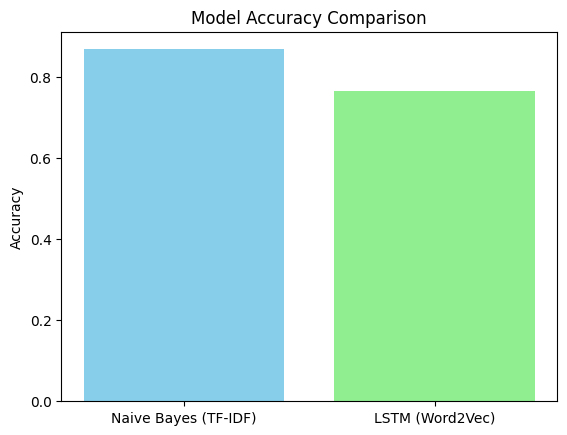

In [27]:
import matplotlib.pyplot as plt

# Plot model accuracy comparison bar graph
models = ['Naive Bayes (TF-IDF)', 'LSTM (Word2Vec)']
accuracies = [accuracy_score(y_test_nb, y_pred_nb), accuracy_score(y_test_lstm, y_pred_lstm)]

plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

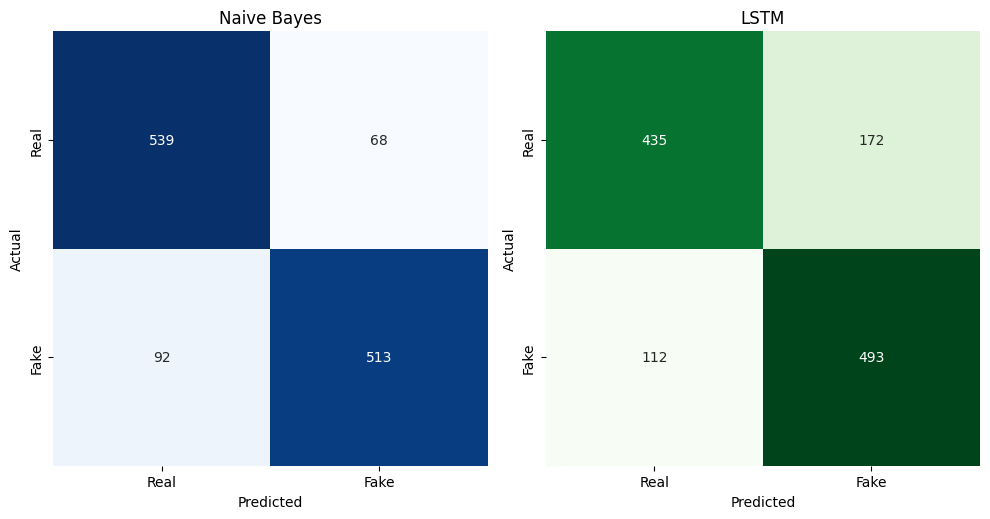

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculation of confusion matrix
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)

# Create subplots for heatmaps
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot Naive-Bayes Confusion Matrix
sns.heatmap(cm_nb, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axs[0])
axs[0].set_title("Naive Bayes")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

# Plot LSTM Confusion Matrix
sns.heatmap(cm_lstm, square=True, annot=True, fmt='d', cbar=False, cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axs[1])
axs[1].set_title("LSTM")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

<h3>Summary</h3>

<p>
This exploratory highlighted the practicality of both Naive-Bayes and LSTM models for fake news detection. Naive-Bayes offers a simple, fast and interpretable solution suitable for real-world environments with limited resources. The LSTM model, using pre-trained word embeddings, captures deeper language patterns but requires more data and tuning to outperform simpler models.

Both approaches can be adapted to other text classification tasks, although deep learning models are complex in nature and require more meticulous adjustments for new domains or datasets. Future improvements could focus on fine-tuning embeddings, increasing dataset size and incorporating additional data types to test and improve the accuracy of fake news detection.
</p>

<h1> References </h1>

[1] https://rm.coe.int/information-disorder-toward-an-interdisciplinary-framework-for-researc/168076277c

[2] https://research-information.bris.ac.uk/ws/portalfiles/portal/152516154/Pages_from_JARMAC_2017_59_Revision_1_V1.pdf

[3] https://www.ipsos.com/en-us/news-polls/cigi-fake-news-global-epidemic

[4] https://ide.mit.edu/wp-content/uploads/2018/12/2017-IDE-Research-Brief-False-News.pdf

[5] https://www.researchgate.net/publication/322128415_Detecting_opinion_spams_and_fake_news_using_text_classification

[6] https://www.researchgate.net/publication/318981549_Fake_News_Detection_on_Social_Media_A_Data_Mining_Perspective

[7] https://www.researchgate.net/publication/329388190_A_Survey_of_Fake_News_Fundamental_Theories_Detection_Methods_and_Opportunities

[8] https://www.kaggle.com/datasets/rajatkumar30/fake-news?select=news.csv

[9] https://cdn.aaai.org/Workshops/1998/WS-98-05/WS98-05-007.pdf